In [1]:
import matplotlib.pyplot as plt

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from scipy.signal import savgol_filter


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/drjohnholash/demo-knes381/subject_1321.xlsx
/kaggle/input/datasets/drjohnholash/demo-knes381/subject_1432.xlsx
/kaggle/input/datasets/drjohnholash/demo-knes381/subject_1321.csv
/kaggle/input/datasets/drjohnholash/demo-knes381/subject_1232.csv
/kaggle/input/datasets/drjohnholash/demo-knes381/VO2_CSV.csv
/kaggle/input/datasets/drjohnholash/demo-knes381/subject_1232.xlsx
/kaggle/input/datasets/drjohnholash/demo-knes381/subject_1432.csv
/kaggle/input/datasets/drjohnholash/demo-knes381/subject_1523.csv
/kaggle/input/datasets/drjohnholash/demo-knes381/VO2_excel.xlsx
/kaggle/input/datasets/drjohnholash/demo-knes381/subject_1523.xlsx


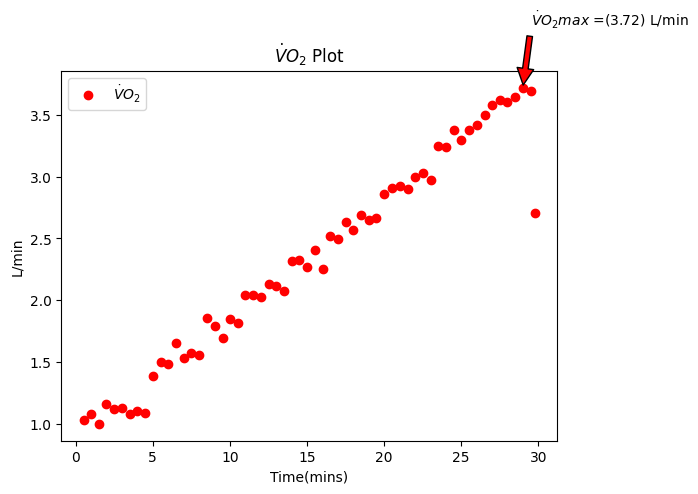

In [2]:
df = pd.read_csv('../input//datasets/drjohnholash/demo-knes381/subject_1432.csv', header=[0], skiprows=[1,2,3])
 
x = df['TIME']
y = df['VO2']

fig, ax = plt.subplots()
ax.plot(x, y,'o', c='r',linewidth=4, label= r'$\dot{V}O_2$')
 
ymax = max(y)

xmax = x[y.argmax()]

ax.annotate(r'$\dot VO_2max$ =({}) L/min'.format(round(ymax, 2)), 
               xy=(xmax, ymax), xytext=(xmax+.5, ymax+ .5),
               arrowprops=dict(facecolor='red', shrink= 0.05),
                )
plt.legend()
plt.xlabel('Time(mins)')  
plt.ylabel('L/min')  
ax.set_title(r'$\dot{V}O_2$ Plot') 


plt.savefig('VO2_plot.png', format='png', dpi=300, bbox_inches='tight')
plt.show()  

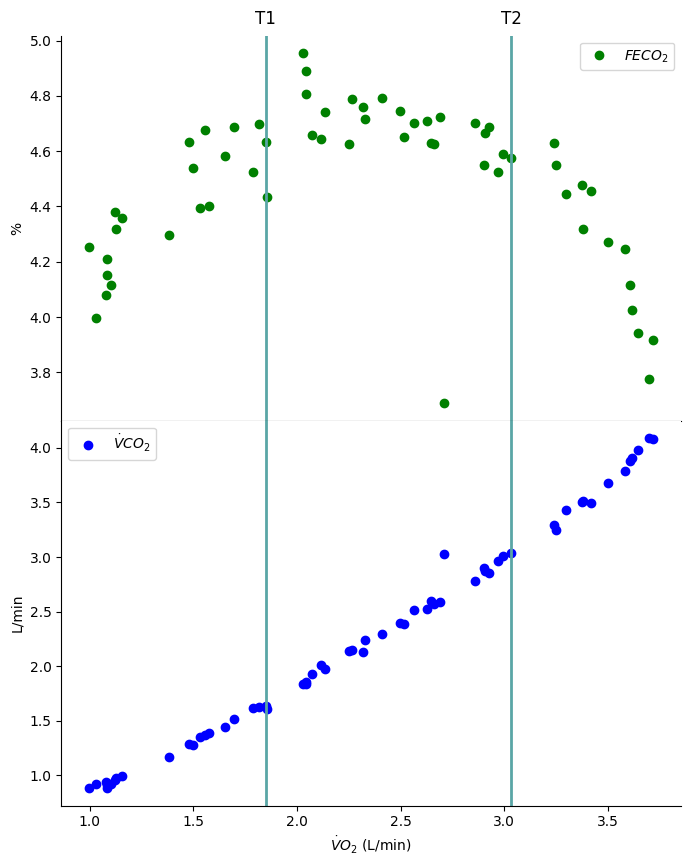

In [3]:
df = pd.read_csv('../input//datasets/drjohnholash/demo-knes381/subject_1432.csv', header=[0], skiprows=[1,2,3])

x = df['VO2']
y = df['FECO2']
y1 = df['VCO2']

ymax = max(y)
xmax = x[y.argmax()]

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 10))

fig.subplots_adjust(hspace=0)

ax[0].plot(x, y, 'o', label=('$FECO_2$'), c='g' )
ax[0].spines[['right', 'top']].set_visible(False)
ax[0].set(ylabel=('%'))
ax[0].legend()

ax[1].plot(x, y1, 'o', label=(r'$\dot{V}CO_2$'), c='b')
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].set(ylabel=('L/min'))
ax[1].set(xlabel=(r'$\dot{V}O_2$ (L/min)'))
ax[1].legend()

get_idx = 19
rcp_idx = 44


vo2 = x
x_get = vo2.iloc[get_idx]
x_rcp = vo2.iloc[rcp_idx]


for a in ax:
    a.axvline(x_get, color='#5aa6a6', linewidth=2)
    a.axvline(x_rcp, color='#5aa6a6', linewidth=2)

ax[0].text(x_get, 1.02, 'T1',
           transform=ax[0].get_xaxis_transform(),
           ha='center', va='bottom', fontsize=12)

ax[0].text(x_rcp, 1.02, 'T2',
           transform=ax[0].get_xaxis_transform(),
           ha='center', va='bottom', fontsize=12)


fig.savefig("FECO2-VCO2-PLOT.png", dpi=300, bbox_inches="tight")
plt.show()
